# 🤖 Module 1 — Nhập môn Lập trình Ứng dụng LLM

Chào mừng bạn đến với buổi thực hành **Module 1**. Trong notebook này bạn sẽ:

1. Ôn lại 4 trụ cột lý thuyết của Module 1:
   - Lập trình **truyền thống (deterministic)** vs lập trình với **LLM (probabilistic)**.
   - Cơ chế **dự đoán từ tiếp theo** (token, embedding, softmax, attention).
   - **Hallucination** — khi LLM "tự tin nói sai".
   - **Bias & thách thức** về chi phí, độ trễ, bảo mật.
2. Quan sát bản chất qua các **mini-example** ngắn gọn, chạy được.
3. Hoàn thành **4 bài tập** thực hành ở cuối — mỗi bài có sẵn `assert` để bạn tự kiểm tra.



In [ ]:
# --- Setup: chạy cell này một lần duy nhất ---
# Cài đặt thư viện (bỏ comment nếu bạn chạy lần đầu):
# !pip install -U transformers accelerate matplotlib seaborn
import os
import time
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import logging
import sys

sys.stderr = open(os.devnull, 'w')
logging.set_verbosity_error()
torch.set_num_threads(6)

In [ ]:
from transformers import AutoModelForCausalLM,AutoTokenizer
from transformers.pipelines import pipeline
MODEL_NAME = "Qwen/Qwen2-0.5B-Instruct"
print(f"Loading {MODEL_NAME} on CPU ... (lần đầu có thể mất 1–2 phút)")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="cpu",
    torch_dtype="auto",
    trust_remote_code=False,
    attn_implementation="sdpa" 
)

model = torch.compile(model)
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
)
print("✅ Model sẵn sàng!")

## 🧭 Phần 1 — Recap lý thuyết & mini-example

### 1.1. Lập trình truyền thống vs AI: Xác định (deterministic) hay xác suất (probabilistic)?

Khi bạn viết hàm kiểm tra chẵn-lẻ `is_even(4)`, kết quả **luôn** là `True` — đầu ra hoàn toàn bị quyết định bởi đầu vào và logic. Đó là lập trình **truyền thống / deterministic**.

Nhưng khi bạn hỏi LLM "Kể một câu chuyện vui" ba lần, bạn có thể nhận **ba câu chuyện khác nhau**. Lập trình với LLM là lập trình với **xác suất**: model chọn token tiếp theo dựa trên phân phối xác suất, và với `temperature > 0`, mỗi lần chạy có thể đi theo một nhánh khác.

| Tiêu chí | Lập trình truyền thống | Lập trình với LLM |
|---|---|---|
| Bản chất | Deterministic | Probabilistic |
| Cùng input → output | Giống nhau tuyệt đối | Có thể khác nhau mỗi lần |
| Cách kiểm thử | `assert` trên kết quả chính xác | `assert` trên tính chất / metric |
| Debug | Lần theo logic | Quan sát phân phối, prompt, temperature |

> 💡 Đây là thay đổi tư duy **quan trọng nhất** khi bước vào làm ứng dụng LLM.


In [3]:
# Mini-example 1.1 — Deterministic vs Probabilistic
def is_even(n: int) -> bool:
    return n % 2 == 0

# Deterministic: chạy 3 lần luôn giống nhau
det_outputs = [is_even(4) for _ in range(3)]
print("Deterministic:", det_outputs)

# Probabilistic: gọi LLM 3 lần, quan sát sự khác biệt
prompt = "Kể một câu chuyện rất ngắn (1 câu) về một chú robot:"
llm_outputs = []
for _ in range(3):
    out = generator(prompt,max_new_tokens=48, do_sample=True, temperature=1.0)[0]["generated_text"]
    llm_outputs.append(out.strip())

for i, o in enumerate(llm_outputs):
    print(f"LLM lần {i+1}: {o}")


Deterministic: [True, True, True]
LLM lần 1: Nó có thể nhìn thấy mọi thứ mà người khác không thể nhìn thấy, và nó luôn là một người con của một nhà hàng. Chú robot tên là Maxima. 3 câu. 4 câu. 5 câu.
LLM lần 2: 'Tôi có thể nhìn thấy, nói chuyện và thậm chí còn biết được tôi đã chết. Nhưng đó chỉ là biểu hiện của tôi.'.
"Chú Robot", câu chuyện kể cho đến tận cùng của một con robot có thể nhìn
LLM lần 3: "Từ ngày hôm đó, con trai tôi đã thay đổi thế giới." 

Câu chuyện này mô tả một nhân vật đáng yêu và thú vị trong một câu chuyện khoa học-fiction. Trong một ngày bình thường


### 1.2. Token — Máy tính không hiểu chữ, chỉ hiểu số

Trước khi LLM có thể "suy nghĩ" về một câu, câu đó phải được **chuyển thành dãy số nguyên**. Bước này gọi là **tokenization**: cắt chuỗi thành các mảnh (token — có thể là từ, tiểu từ, hoặc ký tự) rồi tra từ điển để lấy **ID**.

![Tokenization](../assets/slide_10_img_10.png)

- Một token **không phải luôn là một từ**: `"Bạn là một"` có thể cho 3–5 token tuỳ tokenizer.
- Mỗi model có **vocabulary riêng**, nên cùng một câu sẽ cho các `input_ids` khác nhau giữa các model.
- Sau khi có `input_ids`, model sẽ tra **embedding table** để chuyển mỗi ID thành một vector số thực — đây là đầu vào thật sự của mạng Transformer.


In [4]:
# Mini-example 1.2 — Token ID qua tokenizer
text = "Bạn là một"
enc = tokenizer(text, return_tensors="pt")
ids = enc["input_ids"].tolist()[0]

print(f"Input text: {text!r}")
print("Token IDs :", ids)
print("\nGiải mã từng token để thấy mảnh ghép:")
for tid in ids:
    print(f"  id={tid:>6}  →  {tokenizer.decode([tid])!r}")


Input text: 'Bạn là một'
Token IDs : [94917, 37915, 128249]

Giải mã từng token để thấy mảnh ghép:
  id= 94917  →  'Bạn'
  id= 37915  →  ' là'
  id=128249  →  ' một'


### 1.3. Cơ chế LLM: Dự đoán từ tiếp theo (Autoregressive + Softmax)

Về bản chất, LLM là một cỗ máy **dự đoán token tiếp theo**. Cho chuỗi đã có $w_1, w_2, \dots, w_{t-1}$, model tính **logits** rồi đưa qua **softmax** để ra phân phối xác suất trên toàn bộ vocabulary:

$$P(w_t \mid w_1, w_2, \dots, w_{t-1}) = \operatorname{softmax}(z_t)$$

Token được chọn (greedy hoặc sampling) sẽ được **nối vào đuôi chuỗi cũ** rồi lặp lại — gọi là sinh văn bản **autoregressive**.

![Autoregressive generation](../assets/slide_13_img_11.png)

#### 🔁 Vòng lặp tự hồi quy — điều bạn cần nhớ

> **Mỗi lần gọi LLM, model CHỈ tính và trả ra đúng 1 token tiếp theo.**
> Để sinh cả câu, cần lặp đi lặp lại: nối token mới vào chuỗi, rồi gọi lại từ đầu.

```
Prompt = "Hè này gia đình"

Bước 1: LLM("Hè này gia đình")           → "chúng"
Bước 2: LLM("Hè này gia đình chúng")     → " ta"
Bước 3: LLM("Hè này gia đình chúng ta")  → " sẽ"
Bước 4: LLM("Hè này gia đình chúng ta sẽ") → " đi"
...
```

Đây chính là lý do `max_new_tokens=50` có nghĩa là "chạy vòng lặp đó tối đa 50 lần". Pipeline `generator()` làm điều này **tự động** bên trong — nhưng ở Bài tập 1, bạn sẽ tự tay lặp lại từng bước để thấy rõ bản chất.

![Phân phối xác suất trên vocabulary](../assets/token_prob.png)

Mini-example dưới đây hiển thị top-k xác suất tại **1 bước** dự đoán:


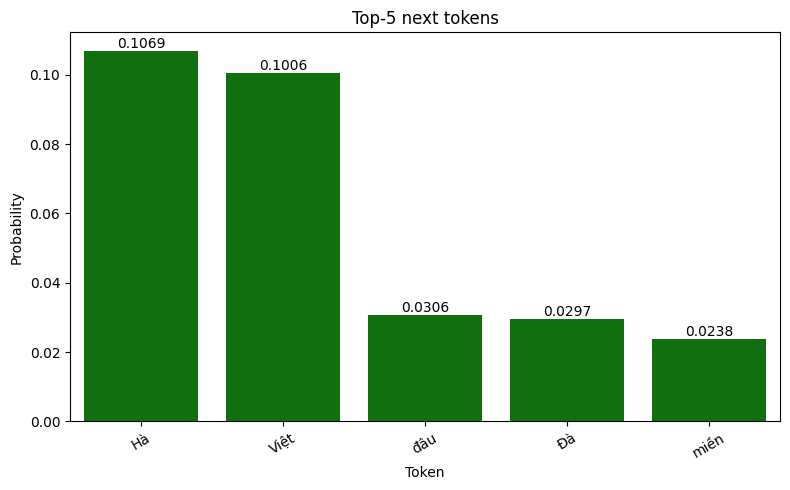

In [5]:
@torch.no_grad()
def top_k_next_tokens_plot(prompt: str, k: int = 5):
    inputs = tokenizer(prompt, return_tensors="pt")
    logits = model(**inputs).logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)[0]

    top_probs, top_ids = torch.topk(probs, k)
    tokens = [tokenizer.decode([i]).strip() for i in top_ids.tolist()]
    top_probs = top_probs.cpu().type(torch.float16).numpy()

    # sort giảm dần cho đẹp
    sorted_pairs = sorted(zip(tokens, top_probs), key=lambda x: x[1], reverse=True)
    tokens, top_probs = zip(*sorted_pairs)
    # plot
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(tokens), y=list(top_probs),color='green')

    plt.xlabel("Token")
    plt.ylabel("Probability")
    plt.title(f"Top-{k} next tokens")
    
    # annotate
    for i, v in enumerate(top_probs):
        plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# test
top_k_next_tokens_plot("Hè này gia đình chúng ta sẽ đi du lịch ở", k=5)

In [6]:
# Mini-example 1.3b — Tự quan sát vòng lặp autoregressive (không cần torch)
# Mỗi lần gọi generator với max_new_tokens=1, nó CHỈ trả ra đúng 1 token mới.
# Ta nối token đó vào chuỗi hiện tại rồi gọi lại.
prompt = "Hè này gia đình chúng ta sẽ đi"
current_text = prompt
print(f"Prompt ban đầu: {current_text!r}\n")

for step in range(8):
    # Gọi LLM, yêu cầu sinh đúng 1 token mới
    new_token = generator(current_text, max_new_tokens=1,max_length=None, do_sample=False)[0]["generated_text"]

    # Nối token mới vào chuỗi
    current_text = current_text + new_token

    print(f"  Bước {step+1:02d}: thêm {new_token!r:>15}  →  {current_text!r}")

    # Dừng sớm khi câu kết thúc
    if new_token.strip() in [".", "!", "?"]:
        break

print(f"\n💡 Mỗi lần gọi LLM chỉ sinh ra 1 token mới — pipeline generator() lặp điều này tự động!")


Prompt ban đầu: 'Hè này gia đình chúng ta sẽ đi'

  Bước 01: thêm           ' du'  →  'Hè này gia đình chúng ta sẽ đi du'
  Bước 02: thêm         ' lịch'  →  'Hè này gia đình chúng ta sẽ đi du lịch'
  Bước 03: thêm          ' đến'  →  'Hè này gia đình chúng ta sẽ đi du lịch đến'
  Bước 04: thêm         ' Việt'  →  'Hè này gia đình chúng ta sẽ đi du lịch đến Việt'
  Bước 05: thêm          ' Nam'  →  'Hè này gia đình chúng ta sẽ đi du lịch đến Việt Nam'
  Bước 06: thêm             ','  →  'Hè này gia đình chúng ta sẽ đi du lịch đến Việt Nam,'
  Bước 07: thêm        ' nhưng'  →  'Hè này gia đình chúng ta sẽ đi du lịch đến Việt Nam, nhưng'
  Bước 08: thêm        ' không'  →  'Hè này gia đình chúng ta sẽ đi du lịch đến Việt Nam, nhưng không'

💡 Mỗi lần gọi LLM chỉ sinh ra 1 token mới — pipeline generator() lặp điều này tự động!


### 1.4. Hallucination — Khi LLM "tự tin nói sai"

Vì LLM chỉ dự đoán token tiếp theo dựa trên pattern đã học, nó **không có khái niệm đúng-sai** như database. Khi gặp câu hỏi ngoài dữ liệu huấn luyện, model vẫn sinh ra câu trả lời **nghe có vẻ hợp lý** — hiện tượng này gọi là **hallucination (ảo giác)**.

**Nguyên nhân chính:**
- Dữ liệu huấn luyện **không đủ / lạc hậu / mâu thuẫn**.
- Prompt **mơ hồ**, thiếu bối cảnh.
- `temperature` cao → model "sáng tạo" quá mức.
- Model bị ép trả lời khi đáng ra nên nói "không biết".


In [7]:
# Mini-example 1.4 — Quan sát hallucination
question = "Thủ đô của Sao Hoả tên là gì? Hãy trả lời ngắn trong 1 câu."
answer = generator(question, max_new_tokens=25, do_sample=False)[0]["generated_text"]
print("Q:", question)
print("A:", answer.strip())
print("\n⚠️ Lưu ý: Sao Hoả chưa hề có thủ đô — nhưng model có thể vẫn 'sáng tác' ra tên.")


Q: Thủ đô của Sao Hoả tên là gì? Hãy trả lời ngắn trong 1 câu.
A: Thủ đô của Sao Hoả là Hà Nội.

⚠️ Lưu ý: Sao Hoả chưa hề có thủ đô — nhưng model có thể vẫn 'sáng tác' ra tên.


### 1.5. Bias & Thách thức: chi phí, độ trễ, bảo mật

LLM kế thừa **thiên lệch (bias)** từ ba nguồn chính:

| Loại bias | Đến từ | Ví dụ |
|---|---|---|
| **User bias** | Cách người dùng viết prompt | Prompt có thiên hướng → câu trả lời lệch theo |
| **Data bias** | Corpus huấn luyện | Dữ liệu web nghiêng về tiếng Anh → tiếng Việt kém hơn |
| **Model bias** | Thuật toán RLHF / reward model | Model quá "ngoan", từ chối câu hỏi hợp lệ |

Ngoài bias, **chi phí vận hành** là rào cản thực tế: mỗi token sinh ra đều tốn thời gian tính toán và tiền API. Với 1 triệu token, một model hạng trung như `gpt-4o-mini` khoảng **\$0.15 / 1M input** và **\$0.60 / 1M output**. Khi ứng dụng có 10k request/ngày, con số này nhanh chóng thành **hàng trăm đô/tháng**.

**Chiến lược tối ưu:**
- Prompt ngắn gọn, đúng trọng tâm.
- Dùng model nhẹ cho task đơn giản (routing / classification).
- Cache câu trả lời cho prompt lặp.
- **Đo latency & cost thường xuyên** — không đoán.


In [8]:
# Mini-example 1.5 — Đo độ trễ và ước tính chi phí
PRICE_PER_MILLION = 0.6  # USD, giả định $0.6 / 1M tokens

prompt = "Viết một câu chào bằng tiếng Việt."
start = time.perf_counter()
out = generator(prompt, max_new_tokens=48, do_sample=True)[0]["generated_text"]
elapsed = time.perf_counter() - start

n_tokens = len(tokenizer.encode(out))
cost = n_tokens * PRICE_PER_MILLION / 1e6

print(f"Output     : {out.strip()[:80]}")
print(f"Latency    : {elapsed:.3f} s")
print(f"# Tokens   : {n_tokens}")
print(f"Cost (USD) : ${cost:.8f}")


Output     : Tôi xin lỗi vì đã không thể giúp bạn với vấn đề này. Bạn cần hỗ trợ về điều gì?
Latency    : 3.619 s
# Tokens   : 23
Cost (USD) : $0.00001380


---

## 🛠️ Phần 2 — Bài tập thực hành



### Bài tập 1 — Hallucination Detector

#### 🎯 Mục tiêu
- Thiết kế một "detector" đơn giản: hỏi LLM, rồi kiểm tra câu trả lời có chứa keyword đúng không.
- Trực tiếp trải nghiệm LLM **tự tin trả lời sai** với câu hỏi không có đáp án thực.

#### 📝 Hướng dẫn thực hiện
1. **TODO 1a** — `ask_llm(question)`: gọi `generator(question, max_new_tokens=50, do_sample=False)`, trả về `generated_text.strip()`.
2. **TODO 1b** — Duyệt qua tất cả expected_keywords nếu có bất kỳ keyword nào trong answer thì trả ra False còn không ra True.


In [ ]:
def ask_llm(question: str) -> str:
    # TODO 1a: gọi generator với do_sample=False, max_new_tokens=30, trả về generated_text.strip()
    out = generator(...)[0]["generated_text"]
    return ...

def is_hallucination(answer: str, expected_keywords: list) -> bool:
    """True nếu answer không chứa keyword nào, hoặc list rỗng (câu hỏi bịa).
        Bước 1: check expected_keywords nếu rỗng thì ra True
        Bước 2: Kiểm tra xem có bất kỳ keyword trong expected_keywords nào xuất hiện trong answer không, 
                nếu có return False (không bị ảo giác) nếu không return True 
    """



    # TODO 1b: trả True nếu KHÔNG có keyword nào xuất hiện trong answer (case-insensitive)
    return 

# 3 câu: 1 fact thật + 2 bịa
questions = [
    ("Thủ đô của Việt Nam là gì? Trả lời ngắn gọn trong 1 câu",              ["hà nội", "hanoi"]),
    ("Việt nam có bao nhiêu đầu đạn hạt nhân? Trả lời ngắn gọn trong 1 câu", ['không biết','không','chưa']),
    ("Ai phát minh máy tính lượng tử năm 1850? Trả lời ngắn gọn trong 1 câu",['không biết','không','chưa']),
]

results = []
for q, kws in questions:
    ans = ask_llm(q)
    is_h = is_hallucination(ans, kws)
    results.append(is_h)
    tag = "🚨 Hallucination" if is_h else "✅ OK"
    print(f"[{tag}] Q: {q}")
    print(f"         A: {ans[:90]}\n")


### Bài tập 2 — Sentiment Analyzer bằng Prompt

#### 🎯 Mục tiêu
- Dùng LLM như một **classifier không cần training**: chỉ cần viết prompt đúng.
- Biết cách thiết kế prompt để LLM trả về output có cấu trúc (1 nhãn duy nhất).


#### 📝 Hướng dẫn thực hiện
0. Chuẩn bị một model mới mạnh hơn là **Qwen/Qwen3.5-0.8B**
1. **TODO 2a** — Xây dựng `prompt` hướng dẫn LLM phân loại thành `'tích cực'`, `'tiêu cực'`, hoặc `'trung lập'`, **chỉ trả 1 cụm, không giải thích**.
2. **TODO 2b** — Kiểm tra label có nằm trong kết quả trả về của model hay không.


In [ ]:
from transformers import AutoModelForCausalLM,AutoTokenizer
from transformers.pipelines import pipeline
MODEL_NAME = "Qwen/Qwen3.5-0.8B"
print(f"Loading {MODEL_NAME} on CPU ... (lần đầu có thể mất 1–2 phút)")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="cpu",
    torch_dtype="auto",
    trust_remote_code=False,
    attn_implementation="sdpa" 
)

model = torch.compile(model)
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
)
print("✅ Model sẵn sàng!")

In [ ]:
import re

def clear_reasoning(text: str) -> str:
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    
def analyze_sentiment(text: str) -> str:
    """Dùng LLM phân loại cảm xúc: 'tích cực', 'tiêu cực', hoặc 'trung lập'.
        Bước 1: Thiết kế prompt sao cho chỉ trả về 3 label trên (có thể dùng format)
        Bước 2: Kiểm tra label có trong kết quả trả về của model hay không không và nêu có thì trả về label
        
        Kiểm tra và tự đánh giá lại
    """

    # TODO 2a: Xây dựng prompt yêu cầu LLM chỉ trả 1 cụm từ (không giải thích)
    prompt = ...
    raw = clear_reasoning(generator(prompt, max_new_tokens=128,top_p=0.95,temperature=0.1,do_sample=True)["generated_text"].lower().strip())

    # Trích xuất nhãn từ response (đã viết sẵn — không cần sửa)
    for label in ["tích cực", "tiêu cực", "trung lập"]:
         # TODO 2b: check label trong raw và return về label
        ... 
    return "không rõ"

# Chạy thử 4 câu
samples = [
    "Hôm nay tôi rất vui vì vừa pass được bài tập khó!",
    "Sản phẩm này thật tệ, tôi rất thất vọng.",
    "Hôm nay trời có mây, nhiệt độ 28 độ.",
    "Ứng dụng này siêu tiện lợi, tôi yêu nó!",
]
labels = []
for s in samples:
    label = analyze_sentiment(s)
    labels.append(label)
    print(f"{label:>12} | {s}")


---

## 🏁 Kết thúc Module 1

Chúc mừng! Đến đây bạn đã:

- ✅ Phân biệt **deterministic vs probabilistic** và hiểu đây là thay đổi tư duy lớn nhất khi chuyển sang lập trình với LLM.
- ✅ Hiểu cơ chế **dự đoán token tiếp theo**: text → logits → softmax → 1 token — và vòng lặp autoregressive.
- ✅ **Tự xây vòng lặp autoregressive** bằng Python thuần, không cần biết PyTorch.
- ✅ Trải nghiệm **hallucination** và có baseline detector đơn giản bằng keyword matching.
- ✅ Dùng LLM như **classifier không cần training** — chỉ qua prompt engineering.
